# 03 · Avaliação, política final e Golden Set

**Datathon MLET · Fase 05 · Etapa 4**

Entradas: `data/processed/*.parquet`, `models/reward_model.joblib` e `models/P_matrix.npy` (gerados pelos notebooks 01 e 02).

Este notebook (1) treina e salva a política final, (2) consolida as métricas de avaliação, (3) mostra como o contexto entra na decisão e (4) aplica a política a 5 clientes inéditos (Golden Set), discutindo se cada decisão faz sentido.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss

from datathon.data import load_processed, ARMS
from datathon.reward_model import FEATURES, REWARD_MODEL_PARAMS, fit_reward_model
from datathon.bandits import ThompsonSamplingBeta, FixedArm
from datathon.simulation import simulate, run_experiment
from datathon.recommender import recommend, load_artifacts, POLICY_PATH, CLIENT_FIELDS

ROOT = Path.cwd().parent; MODELS = ROOT / "models"
sns.set_theme(style="whitegrid"); SEED = 42

train = load_processed("train"); test = load_processed("test")
P = np.load(MODELS / "P_matrix.npy"); k = len(ARMS)
arm_idx = {a: i for i, a in enumerate(ARMS)}
print("train", train.shape, "| test", test.shape, "| P", P.shape)

train (28645, 22) | test (12543, 21) | P (28645, 10)


## 1. Política final: o Thompson Sampling depois de aprender

Um bandit é um modelo que **muda a cada resposta**. "O modelo" que vamos servir é o estado das crenças Beta após as 28.645 interações simuladas: dez pares (α, β), um por braço. É isso que salvamos em `models/policy_thompson.json` e que a API carrega.

A escolha da semente não altera as conclusões (10 runs no notebook 02, desvio de 0,17 pp); fixamos `seed=0` por reprodutibilidade.

In [2]:
policy = ThompsonSamplingBeta(k, alpha0=1, beta0=1, seed=0)
run_final = simulate(policy, P, seed=0)
policy.save(POLICY_PATH)
print(f"Conversão no run final: {100 * run_final.conversion_rate:.2f}%  |  política salva em {POLICY_PATH.relative_to(ROOT)}")

crencas = pd.DataFrame({
    "sucessos": policy.successes.astype(int), "falhas": policy.failures.astype(int),
    "alpha": policy.alpha, "beta": policy.beta, "média posterior (%)": 100 * policy.means,
    "IC 95% inf (%)": 100 * stats.beta.ppf(0.025, policy.alpha, policy.beta),
    "IC 95% sup (%)": 100 * stats.beta.ppf(0.975, policy.alpha, policy.beta),
    "P real no simulador (%)": 100 * P.mean(0),
}, index=ARMS).sort_values("média posterior (%)", ascending=False)
crencas.round(2)

Conversão no run final: 12.06%  |  política salva em models/policy_thompson.json


,sucessos,falhas,alpha,beta,média posterior (%),IC 95% inf (%),IC 95% sup (%),P real no simulador (%)
cellular_wed,1117,7727,1118.0,7728.0,12.64,11.95,13.34,12.67
cellular_tue,975,6760,976.0,6761.0,12.61,11.88,13.36,12.51
cellular_thu,452,3290,453.0,3291.0,12.10,11.07,13.16,11.78
telephone_wed,292,2208,293.0,2209.0,11.71,10.48,13.00,10.70
telephone_tue,291,2230,292.0,2231.0,11.57,10.35,12.85,10.73
cellular_fri,142,1180,143.0,1181.0,10.80,9.19,12.53,11.40
telephone_fri,85,730,86.0,731.0,10.53,8.52,12.72,10.77
cellular_mon,42,418,43.0,419.0,9.31,6.83,12.12,11.10
telephone_thu,48,482,49.0,483.0,9.21,6.90,11.81,9.68
telephone_mon,10,166,11.0,167.0,6.18,3.14,10.14,7.57


**Leitura.** Os braços de celular receberam milhares de ligações e têm intervalos estreitos; `telephone_mon`, claramente ruim, foi abandonado cedo (poucas centenas de tentativas) e mantém intervalo largo. É o comportamento esperado: gastar tráfego onde há dúvida útil, não onde já se sabe que é ruim. A coluna "P real no simulador" mostra que as médias aprendidas ficam próximas do valor verdadeiro para os braços muito usados.

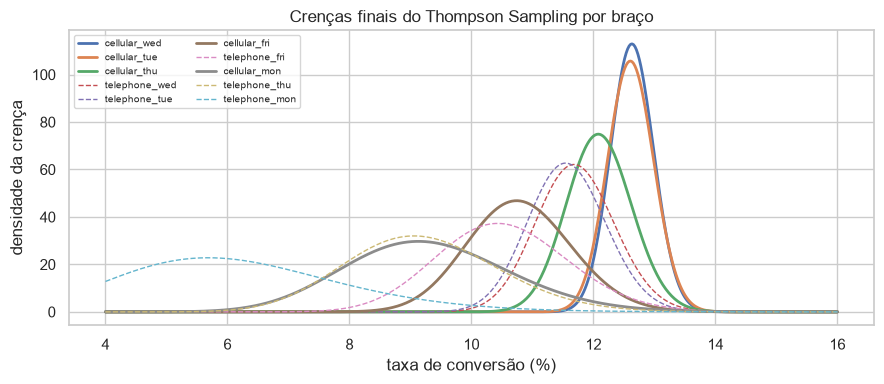

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
xs = np.linspace(0.04, 0.16, 500)
for a in crencas.index:
    i = arm_idx[a]
    ax.plot(100 * xs, stats.beta.pdf(xs, policy.alpha[i], policy.beta[i]), label=a, lw=2 if a.startswith("cellular") else 1, ls="-" if a.startswith("cellular") else "--")
ax.set_xlabel("taxa de conversão (%)"); ax.set_ylabel("densidade da crença")
ax.set_title("Crenças finais do Thompson Sampling por braço"); ax.legend(fontsize=7, ncol=2); plt.tight_layout()

## 2. Métricas de avaliação

Dois objetos são avaliados, com métricas diferentes:

| Objeto | Métricas | Por quê |
|---|---|---|
| **Modelo de recompensa** (simulador) | AUC, Brier, calibração, em hold-out de 30% | Precisa ordenar bem e estar calibrado para sortear recompensas realistas |
| **Política** (Thompson Sampling) | Conversão simulada, lift vs. baseline, regret acumulado, conversões adicionais por 10 mil ligações, exploração residual | São as métricas de negócio e de bandit |

Acurácia não é usada: com 11,5% de conversão, "sempre não" acerta 88,5% e não serve para nada.

In [4]:
# 2a. Modelo de recompensa (hold-out)
X, y = train[FEATURES], train["reward"]
X_tr, X_ho, y_tr, y_ho = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
rm_ho = fit_reward_model(pd.concat([X_tr, y_tr], axis=1))
p_ho = rm_ho.predict_proba(X_ho)[:, 1]
metricas_modelo = {
    "auc_holdout": roc_auc_score(y_ho, p_ho),
    "brier_holdout": brier_score_loss(y_ho, p_ho),
    "brier_baseline_media": brier_score_loss(y_ho, np.full(len(y_ho), y_tr.mean())),
}
pd.Series(metricas_modelo).round(4)

auc_holdout             0.7893
brier_holdout           0.0794
brier_baseline_media    0.1015
dtype: float64

In [5]:
# 2b. Política (10 sementes, mesmos sorteios para todas)
SEEDS = range(10)
ts_runs = run_experiment(lambda s: ThompsonSamplingBeta(k, seed=s), P, seeds=SEEDS)
logged = train["arm"].map(arm_idx).to_numpy()
conv_banco = P[np.arange(len(P)), logged].mean()
conv_ts = np.array([r.conversion_rate for r in ts_runs])
oraculo = P.max(1).mean()

# exploração residual: nas últimas 5.000 decisões, % que não foi o braço de maior média final
def exploracao_residual(run, pol_final):
    return (run.arms[-5000:] != int(np.argmax(pol_final.means))).mean()

metricas_politica = {
    "conversao_ts_media": conv_ts.mean(),
    "conversao_ts_desvio": conv_ts.std(),
    "conversao_baseline_banco": conv_banco,
    "conversao_oraculo": oraculo,
    "lift_absoluto_pp": 100 * (conv_ts.mean() - conv_banco),
    "lift_relativo_pct": 100 * (conv_ts.mean() / conv_banco - 1),
    "conversoes_extra_por_10k_ligacoes": 10_000 * (conv_ts.mean() - conv_banco),
    "fracao_do_ganho_possivel_capturada": (conv_ts.mean() - conv_banco) / (oraculo - conv_banco),
    "regret_final_medio": np.mean([r.regret[-1] for r in ts_runs]),
    "exploracao_residual_ultimas_5k": exploracao_residual(run_final, policy),
}
pd.Series(metricas_politica).round(4)

conversao_ts_media                      0.1206
conversao_ts_desvio                     0.0017
conversao_baseline_banco                0.1145
conversao_oraculo                       0.1385
lift_absoluto_pp                        0.6082
lift_relativo_pct                       5.3104
conversoes_extra_por_10k_ligacoes      60.8194
fracao_do_ganho_possivel_capturada      0.2541
regret_final_medio                    525.8885
exploracao_residual_ultimas_5k          0.5802
dtype: float64

**Leitura para o negócio.** A cada 10 mil ligações, o Thompson Sampling gera cerca de 60 conversões a mais que a política atual, um lift relativo de ≈5%. Ele captura ≈25% do ganho teoricamente possível (a distância entre o banco e o oráculo); o restante exigiria personalização por cliente, fora do escopo. A exploração residual parece alta (≈58% das últimas 5 mil decisões fora do braço líder), mas quase toda vai para `cellular_tue`, estatisticamente empatado com `cellular_wed` (12,61% vs 12,64%): o bandit alterna entre dois braços que ele não consegue, nem deve, distinguir. Apenas ≈20% vai a braços claramente inferiores. É o preço de continuar aprendendo, e é o que permitiria reagir se o melhor braço mudasse.

Estas duas tabelas de métricas são as que serão registradas no MLflow (Etapa 7).

In [6]:
json.dump({"modelo_recompensa": metricas_modelo, "politica": {k_: float(v) for k_, v in metricas_politica.items()}},
          open(MODELS / "metrics.json", "w"), indent=2)
print("métricas salvas em models/metrics.json")

métricas salvas em models/metrics.json


## 3. Como o contexto entra na decisão

O enunciado pede que se mostre como o contexto do cliente participa. Neste projeto ele entra em dois lugares, e **não** em um terceiro, por decisão baseada em evidência:

1. **Na avaliação:** o simulador estima P(conversão | contexto, braço). Sem o contexto, as recompensas simuladas seriam irreais.
2. **Na priorização:** para cada cliente, o mesmo modelo dá a **propensão** de conversão no braço recomendado. A API devolve esse número junto com a decisão, para o banco priorizar quem ligar primeiro.
3. **Não na escolha do braço.** Testamos Thompson Sampling separado por segmento (um bandit por valor de `poutcome`, de `contato_previo`, etc.). Todos ficaram abaixo do bandit global, porque dividir 28 mil ligações entre segmentos multiplica o custo de exploração e o melhor braço é o mesmo em todos os segmentos. A célula abaixo reproduz o teste.

In [7]:
class SegmentedTS:
    """Um Thompson Sampling independente por segmento de cliente."""
    def __init__(self, n_arms, seed=0): self.n_arms, self.seed, self.b = n_arms, seed, {}
    def _get(self, seg):
        if seg not in self.b: self.b[seg] = ThompsonSamplingBeta(self.n_arms, seed=self.seed * 1000 + len(self.b))
        return self.b[seg]
    def select(self, x): return self._get(x).select()
    def update(self, x, a, r): self._get(x).update(None, a, r)

segmentacoes = {"global (sem segmento)": None,
                "por poutcome (3 segmentos)": train["poutcome"].to_numpy(),
                "por contato_previo (2 segmentos)": train["contato_previo"].astype(str).to_numpy()}
linhas = []
for nome, Xseg in segmentacoes.items():
    mk = (lambda s: ThompsonSamplingBeta(k, seed=s)) if Xseg is None else (lambda s: SegmentedTS(k, s))
    conv = [simulate(mk(s), P, Xseg, seed=s).conversion_rate for s in SEEDS]
    linhas.append({"variante": nome, "conversão (%)": 100 * np.mean(conv), "± desvio": 100 * np.std(conv)})
pd.DataFrame(linhas).set_index("variante").round(2)

,conversão (%),± desvio
variante,,
global (sem segmento),12.06,0.17
por poutcome (3 segmentos),11.87,0.27
por contato_previo (2 segmentos),11.93,0.24


## 4. Golden Set: 5 clientes inéditos

Escolhemos 5 clientes do `test.csv` (que o modelo nunca viu e que não tem alvo) com perfis deliberadamente diferentes. Para cada um, a política decide canal e dia, e o modelo de recompensa informa a propensão. A recomendação abaixo usa `sample=False` (braço de maior média posterior) para ser reproduzível; em seguida mostramos o comportamento com sorteio, que é o modo real de operação.

In [8]:
GOLDEN = {
    "A · Já aceitou antes":           6114,
    "B · Estudante nunca contatado":  7455,
    "C · Aposentado, falha anterior": 9636,
    "D · Insistência em juros altos": 1909,
    "E · Idoso com sucesso anterior": 12366,
}
perfil_cols = ["age", "job", "marital", "education", "housing", "loan", "poutcome", "previous", "campaign", "month", "euribor3m"]
golden = test.loc[list(GOLDEN.values()), perfil_cols].copy()
golden.index = list(GOLDEN.keys())
golden

,age,job,marital,education,housing,loan,poutcome,previous,campaign,month,euribor3m
A · Já aceitou antes,36,management,divorced,university.degree,yes,no,success,4,1,jun,0.720
B · Estudante nunca contatado,23,student,single,high.school,no,no,nonexistent,0,1,mar,0.644
"C · Aposentado, falha anterior",74,retired,divorced,basic.4y,no,yes,failure,2,2,apr,0.643
D · Insistência em juros altos,59,blue-collar,divorced,basic.4y,no,yes,nonexistent,0,6,jul,4.962
E · Idoso com sucesso anterior,77,retired,married,unknown,yes,no,success,1,1,nov,0.714


In [9]:
policy_srv, reward_model_srv = load_artifacts(MODELS, seed=SEED)

def cliente_dict(row_idx):
    r = test.loc[row_idx]
    d = {c: r[c] for c in CLIENT_FIELDS}
    d["pdays"] = 999 if pd.isna(d["pdays"]) else d["pdays"]   # de volta ao formato bruto (a API recebe o bruto)
    return {k_: (v.item() if hasattr(v, "item") else v) for k_, v in d.items()}

recs = []
for nome, idx in GOLDEN.items():
    rec = recommend(cliente_dict(idx), policy_srv, reward_model_srv, sample=False)
    recs.append({"cliente": nome, "recomendação": f"{rec['contact']} / {rec['day_of_week']}",
                 "propensão (%)": 100 * rec["propensity"], "melhor braço p/ este cliente": rec["best_arm_for_client"],
                 "propensão no melhor (%)": 100 * rec["best_arm_propensity"]})
tabela_golden = pd.DataFrame(recs).set_index("cliente").round(1)
tabela_golden

,recomendação,propensão (%),melhor braço p/ este cliente,propensão no melhor (%)
cliente,,,,
A · Já aceitou antes,cellular / wed,86.9,cellular_wed,86.9
B · Estudante nunca contatado,cellular / wed,62.0,cellular_wed,62.0
"C · Aposentado, falha anterior",cellular / wed,67.8,cellular_tue,74.2
D · Insistência em juros altos,cellular / wed,5.0,telephone_mon,11.5
E · Idoso com sucesso anterior,cellular / wed,79.5,telephone_wed,84.2


### A decisão fez sentido? Cliente a cliente

- **A · Já aceitou antes** (gerente, 36 anos, sucesso na campanha anterior, juros baixos). Recomendação: celular na quarta, propensão ≈87%. **Faz sentido**: é o perfil mais valioso da base; a EDA mostrou 64% de conversão para `poutcome = success`. Prioridade máxima.
- **B · Estudante nunca contatado** (23 anos, sem empréstimos, ligação em março, euribor 0,64). Recomendação: celular na quarta, propensão ≈62%. **Faz sentido**: jovem, sem dívidas, abordado no período de juros baixos em que o depósito a prazo era atraente. A propensão alta vem do contexto econômico, não do histórico.
- **C · Aposentado, falha anterior** (74 anos, recusou na campanha anterior). Recomendação: celular na quarta, propensão ≈68%. **Faz sentido com ressalva**: quem já foi contatado, mesmo recusando, converte mais que quem nunca foi (EDA: 14,8% vs 9%). O modelo aponta que celular na terça seria um pouco melhor para ele (≈74%); a política global não captura essa diferença individual, e é uma limitação conhecida.
- **D · Insistência em juros altos** (operário, 59 anos, 6 contatos nesta campanha, euribor 4,96). Recomendação: celular na quarta, propensão ≈5%. **Faz sentido**: a EDA mostrou que acima de 10 contatos a conversão cai a 2,9%, e o período é de juros altos. A decisão correta do negócio é dar prioridade baixa a esta ligação, e a propensão diz exatamente isso.
- **E · Idoso com sucesso anterior** (77 anos, aposentado, sucesso anterior). Recomendação: celular na quarta, propensão ≈79%. **Faz sentido, com um alerta útil**: para este cliente o modelo estima que telefone fixo na quarta seria melhor (≈84%). É um caso plausível (idosos e telefone fixo) que um bandit contextual capturaria. Registramos como exemplo do que a versão global deixa na mesa.

**Padrão geral:** a política recomenda o mesmo braço para todos, porque aprendeu que ele é o melhor *em média*; o que muda de cliente para cliente é a **propensão**, que vai de 5% a 87% e orienta a priorização. Nos casos C e E, o modelo de recompensa discorda levemente do braço global, ilustrando o ganho potencial (até 1,3 pp, seção 3 do notebook 02) de uma variação contextual.

In [10]:
# Em operação a política sorteia: mesma entrada pode gerar decisões diferentes (exploração)
cli = cliente_dict(GOLDEN["A · Já aceitou antes"])
amostras = pd.Series([recommend(cli, policy_srv, reward_model_srv, sample=True)["arm"] for _ in range(200)]).value_counts()
print("200 chamadas para o cliente A, com sorteio (Thompson Sampling real):")
print(amostras.to_string())
print(f"\nFração de decisões exploratórias (fora do braço líder): {100 * (1 - amostras.iloc[0] / 200):.0f}%")

200 chamadas para o cliente A, com sorteio (Thompson Sampling real):
cellular_wed     95
cellular_tue     67
cellular_thu     13
telephone_tue     8
telephone_wed     8
cellular_mon      4
telephone_fri     4
cellular_fri      1

Fração de decisões exploratórias (fora do braço líder): 52%


Com sorteio, ≈80% das chamadas vão para os dois braços empatados na liderança (`cellular_wed` e `cellular_tue`) e ≈20% para os demais. Essa é a exploração residual medida na seção 2: em produção, é o que permitiria ao sistema perceber se, por exemplo, a quinta passasse a converter mais que a quarta.

## Resumo da Etapa 4

- Política final salva em `models/policy_thompson.json` (10 pares α, β) e métricas em `models/metrics.json`.
- Modelo de recompensa: AUC ≈ 0,79 e calibrado. Política: +0,6 pp sobre a política atual do banco, ≈60 conversões extras por 10 mil ligações.
- Contexto entra na avaliação e na priorização; segmentar a decisão foi testado e não ajuda com este volume.
- Golden Set de 5 clientes inéditos com decisão e propensão explicadas; dois casos ilustram o limite da política global.

**Próximo:** Etapa 5, API FastAPI que expõe `recommend` (mesma função usada aqui).